/tmp/ipykernel_1191/753968108.py:62: FutureWarning: `torch.nn.utils.clip_grad_norm` is now deprecated in favor of `torch.nn.utils.clip_grad_norm_`.
  torch.nn.utils.clip_grad_norm(model.parameters(),max_norm=1.0)


Epoch 0 | Train Loss: 0.025565 | Val Loss: 0.011940
Epoch 20 | Train Loss: 0.000012 | Val Loss: 0.000015
Epoch 40 | Train Loss: 0.000008 | Val Loss: 0.000009
Epoch 60 | Train Loss: 0.000019 | Val Loss: 0.000018
Epoch 80 | Train Loss: 0.000015 | Val Loss: 0.000009
Epoch 100 | Train Loss: 0.000007 | Val Loss: 0.000028
Epoch 120 | Train Loss: 0.000012 | Val Loss: 0.000010
Epoch 140 | Train Loss: 0.000011 | Val Loss: 0.000034
Epoch 160 | Train Loss: 0.000004 | Val Loss: 0.000005
Epoch 180 | Train Loss: 0.000005 | Val Loss: 0.000004

Best model at epoch 108 with val loss 0.000004


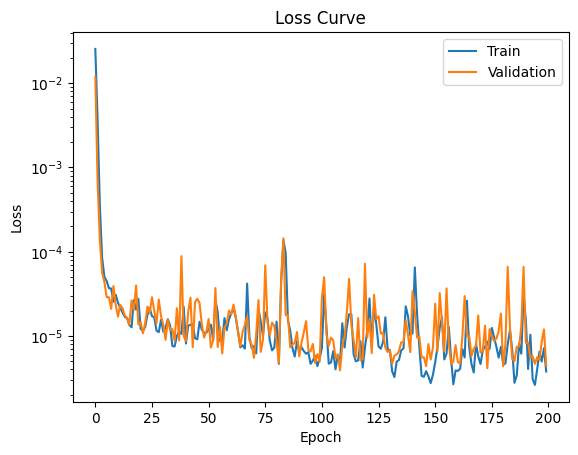

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

x=torch.linspace(-3,3,50)
y=torch.linspace(-3,3,50)
X,Y=torch.meshgrid(x,y,indexing='ij')
z=torch.flatten(torch.exp(-(X**2+Y**2))).view(-1,1)
xy=torch.stack([X.flatten(),Y.flatten()],dim=1)

indices=torch.randperm(xy.shape[0])
xy=xy[indices]
z=z[indices]

split=int(0.8*len(xy))
xy_train,xy_val=xy[:split], xy[split:]
z_train,z_val= z[:split], z[split:]

dataset= TensorDataset(xy_train,z_train)
dataloader=DataLoader(dataset,batch_size=32,shuffle=True)

class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.input=nn.Linear(2,32)
    self.l1=nn.Linear(32,32)
    self.l2=nn.Linear(32,32)
    self.l3=nn.Linear(32,32)
    self.output=nn.Linear(32,1)

  def forward(self,xy):
    xy=torch.relu(self.input(xy))
    xy=torch.relu(self.l1(xy))
    xy=torch.relu(self.l2(xy))
    xy=torch.relu(self.l3(xy))
    xy=self.output(xy)

    return xy

model=Net()
optimizer=optim.Adam(model.parameters(),lr=0.001)
criterion=nn.MSELoss()

train_losses=[]
val_losses=[]

best_val_loss=float('inf')
best_epoch=0


for epoch in range(200):
  model.train()
  epoch_loss=0

  for batch_xy, batch_z  in dataloader:
    optimizer.zero_grad()
    pred=model(batch_xy)
    loss=criterion(pred,batch_z)
    loss.backward()
    torch.nn.utils.clip_grad_norm(model.parameters(),max_norm=1.0)
    optimizer.step()
    epoch_loss+=loss.item()

  avg_train_loss=epoch_loss/len(dataloader)
  train_losses.append(avg_train_loss)

  model.eval()
  with torch.no_grad():
    val_pred=model(xy_val)
    val_loss=criterion(val_pred,z_val).item()
  val_losses.append(val_loss)

  if val_loss<best_val_loss:
    best_val_loss=val_loss
    best_epoch=epoch
    torch.save(model.state_dict(),'best_model.pt')

  if epoch % 20 == 0:
    print(f'Epoch {epoch} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}')

model.load_state_dict(torch.load('best_model.pt'))
print(f'\nBest model at epoch {best_epoch} with val loss {best_val_loss:.6f}')

plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

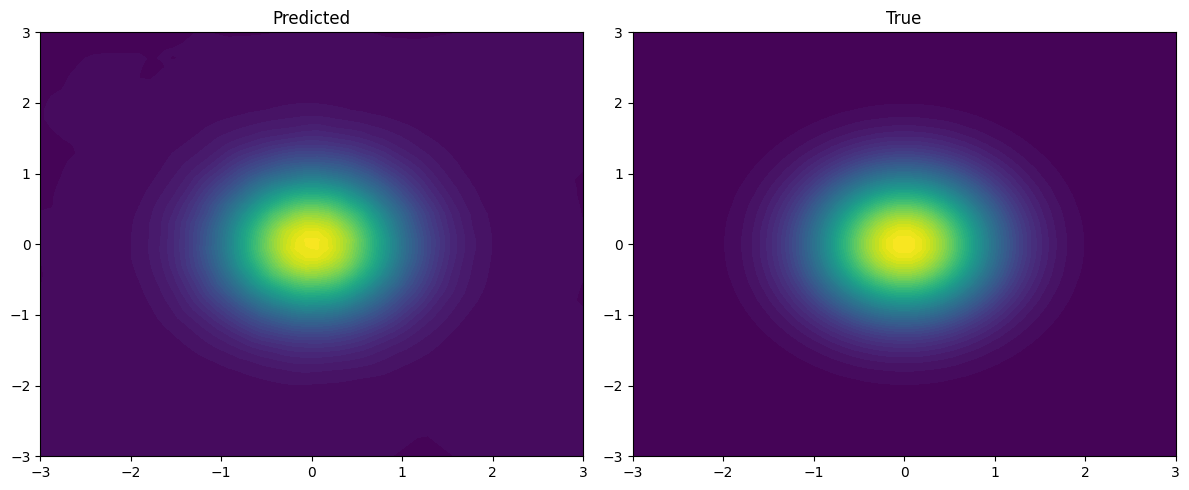

In [3]:
# Regenerate clean grid for plotting
x_plot = torch.linspace(-3, 3, 50)
y_plot = torch.linspace(-3, 3, 50)
X_plot, Y_plot = torch.meshgrid(x_plot, y_plot, indexing='ij')
xy_plot = torch.stack([X_plot.flatten(), Y_plot.flatten()], dim=1)

model.eval()
with torch.no_grad():
    zpred = model(xy_plot).reshape(50, 50)

z_true = torch.exp(-(X_plot**2 + Y_plot**2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].contourf(X_plot.numpy(), Y_plot.numpy(), zpred.numpy(), levels=50, cmap='viridis')
axes[0].set_title('Predicted')
axes[1].contourf(X_plot.numpy(), Y_plot.numpy(), z_true.numpy(), levels=50, cmap='viridis')
axes[1].set_title('True')
plt.tight_layout()
plt.show()


Observations:

1. ReLU is a better default than tanh for functions that don't have large oscillations
2. Always use a separate ordered grid for plotting — never plot on shuffled training data
3. The shuffling bug produced a plot that looked completely wrong despite the model being correct — visual debugging matters
4. The peak is still the hardest region to fit, consistent across every problem